### Packages  

In [39]:
from pathlib import Path
import pandas as pd
import matplotlib as plt 
import matplotlib.pyplot as plt
import numpy as np


### Paths to annotated datasets

In [40]:
# FED SIDE
STATEMENTS_PATH_FED = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/FOMC STATEMENTS/fomc_statements_train_1000.xls")
PRESCONF_PATH_FED   = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Press Conferences/presconf_to_annotate.xlsx")
SPEECHES_PATH_FED   = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/FED/Annotated/Speeches/Annotated with Shah Merge/lab-manual-sp-train-5768-augmented.xlsx")
# ECB SIDE
STATEMENTS_PATH_ECB   = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/ecb_train-2.xls")
STATEMENTS_PATH_ECB_2 = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/ecb_test.csv")
PRESCONF_PATH_ECB   = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/ecb_Press Conference Statements + QA_to_annotate.xlsx")
SPEECHES_PATH_ECB   = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/data/ECB/Annotated/speeches_annotated_v3.xlsx")
# Statment merge on the ECB side, from train and test split. 
stat_1_EU = pd.read_excel(STATEMENTS_PATH_ECB, header=1)
stat_2_EU = pd.read_csv(STATEMENTS_PATH_ECB_2)
merged_ECB_Statement= pd.concat([pd.read_excel(STATEMENTS_PATH_ECB, header=1), pd.read_csv(STATEMENTS_PATH_ECB_2)], ignore_index=True)

stat_fed = pd.read_excel(STATEMENTS_PATH_FED)
press_fed = pd.read_excel(PRESCONF_PATH_FED)
press_ecb = pd.read_excel(PRESCONF_PATH_ECB)
speech_fed = pd.read_excel(SPEECHES_PATH_FED)
speech_ecb = pd.read_excel(SPEECHES_PATH_ECB)




Index Builder

In [41]:
# Index Buliding function for the ECB and FED datasets.
def build_index(df, freq, label_col):
    """Measure per period. freq: 'Q' = quarterly, 'A' = yearly."""
    df = df.copy()
    df[label_col] = df[label_col].replace({'MD': 'D', 'MH': 'H'})
    counts = df.groupby([pd.Grouper(key="date", freq=freq), label_col]).size().unstack(fill_value=0)
    index = (counts.get("H", 0) - counts.get("D", 0)) / counts.sum(axis=1)
    return index

def build_index_speech(df, freq, label_col):
    """Measure per period. freq: 'Q' = quarterly, 'A' = yearly."""
    df = df.copy()
    df[label_col] = df[label_col].replace({'MD': 'D', 'MH': 'H'})
    counts = df.groupby([pd.Grouper(key="year", freq=freq), label_col]).size().unstack(fill_value=0)
    index = (counts.get("H", 0) - counts.get("D", 0)) / counts.sum(axis=1)
    return index


# Datetime conversion for the date columns in the datasets.
stat_fed["date"] = pd.to_datetime(
    stat_fed["date"], errors="coerce"
)
merged_ECB_Statement["date"] = pd.to_datetime(
    merged_ECB_Statement["date"], errors="coerce"
)
press_fed["date"] = pd.to_datetime(
    press_fed["date"], errors="coerce"
)
press_ecb["date"] = pd.to_datetime(
    press_ecb["date"], errors="coerce"
)
speech_fed["year"] = pd.to_datetime(
    speech_fed["year"], errors="coerce"
)
speech_ecb["date"] = pd.to_datetime(
    speech_ecb["date"], errors="coerce"
)

stat_fed_index = build_index(stat_fed, 'QE', 'label').rename('Hawkish-Dovish Index (FED Statements)')
stat_ecb_index = build_index(merged_ECB_Statement, 'QE', 'label').rename('Hawkish-Dovish Index (ECB Statements)')
press_fed_index = build_index(press_fed, 'QE', 'label').rename('Hawkish-Dovish Index (FED Press Conf)')
press_ecb_index = build_index(press_ecb, 'QE', 'label').rename('Hawkish-Dovish Index (ECB Press Conf)')
speech_fed_index = build_index_speech(speech_fed, 'YE', 'label').rename('Hawkish-Dovish Index (FED Speeches)')
speech_ecb_index = build_index(speech_ecb, 'QE', 'label').rename('Hawkish-Dovish Index (ECB Speeches)')

/var/folders/k1/mhyzg0w15gb04d0x6q7gdp2w0000gn/T/ipykernel_48601/295077000.py:23: UserWarning:

Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



Distrbution Hawkish Dovish Amoung Each Document

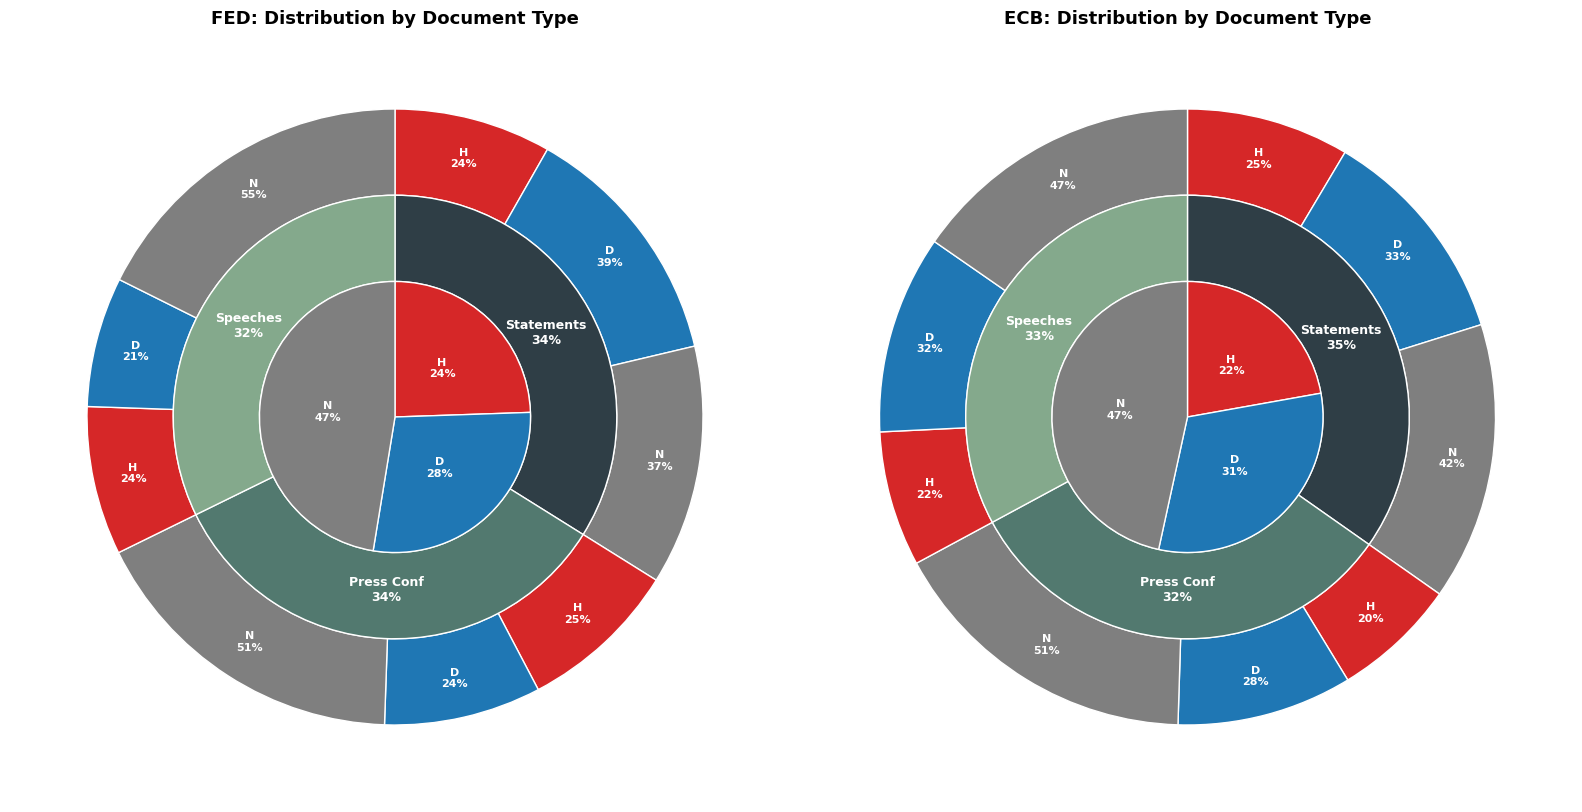

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

colors = {'H': '#d62728', 'D': '#1f77b4', 'N': '#7f7f7f'}
doc_order = ['Statements', 'Press Conf', 'Speeches']
label_order = ['H', 'D', 'N']

def nested_donut(df, title, ax):
    docs = [d for d in doc_order if d in df['doc_type'].unique()]
    inner_sizes, outer_sizes, outer_colors, outer_labels = [], [], [], []

    for d in docs:
        sub = df[df['doc_type'] == d]
        inner_sizes.append(len(sub))
        for l in label_order:
            n = (sub['label'] == l).sum()
            if n > 0:
                outer_sizes.append(n)
                outer_colors.append(colors[l])
                outer_labels.append(f'{l}\n{n/len(sub)*100:.0f}%')

    inner_colors = inner_colors = ['#2f3e46', '#52796f', '#84a98c']  # charcoal-slate, muted teal-grey, sage
    size = 0.28
    # OUTER ring = H/D/N per doc type
    ax.pie(outer_sizes, radius=1, colors=outer_colors,
           labels=outer_labels, labeldistance=0.87,
           startangle=90, counterclock=False,
           wedgeprops=dict(width=size, edgecolor='w'),
           textprops={'fontsize': 8, 'color': 'white', 'ha': 'center', 'weight': 'bold'})

    # MIDDLE ring = doc type
    ax.pie(inner_sizes, radius=1-size, colors=inner_colors,
           labels=[f'{d}\n{s/sum(inner_sizes)*100:.0f}%' for d, s in zip(docs, inner_sizes)],
           labeldistance=0.78,
           startangle=90, counterclock=False,
           wedgeprops=dict(width=size, edgecolor='w'),
           textprops={'fontsize': 9, 'color': 'white', 'ha': 'center', 'weight': 'bold'})

    # CENTER = overall H/D/N split (solid pie)
    center_sizes = [(df['label'] == l).sum() for l in label_order]
    center_colors = [colors[l] for l in label_order]
    center_labels = [f'{l}\n{s/sum(center_sizes)*100:.0f}%' if s > 0 else '' for l, s in zip(label_order, center_sizes)]
    ax.pie(center_sizes, radius=1-2*size, colors=center_colors,
           labels=center_labels, labeldistance=0.5,
           startangle=90, counterclock=False,
           wedgeprops=dict(edgecolor='w'),
           textprops={'fontsize': 8, 'color': 'white', 'ha': 'center', 'weight': 'bold'})

    ax.set_title(title, fontsize=13, fontweight='bold')


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
nested_donut(fed_all, 'FED: Distribution by Document Type', axes[0])
nested_donut(ecb_all, 'ECB: Distribution by Document Type', axes[1])
plt.tight_layout()
plt.show()

Distribution and Descriptive Statistics 